In [1]:
import gurobipy as gp
import math
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import re
import os
import shutil

In [2]:
# output generation for paper 3

In [3]:
# get input paths
test_set = "miplib3" # todo update this as needed
instance_fldr = os.path.join("instances", test_set)
test_set_fldr = os.path.join("test_sets", test_set)
results_fldr = os.path.join("results", test_set)
out_fldr = os.path.join("outputs", test_set)

# set filters
seed_idxs = [0]  
max_indices = 2
degrees = [-1, 1]  # todo update this as needed
term_list = [4, 16, 64]  # todo update this as needed
filter_cbc = False
max_base_std = 1e10
min_termination_time = 0  # todo update this as needed - fitler wins on default runs that took at least 10 seconds
short, medium, long = 60, 600, 3600
remove_status_changes = False
win_threshold = .2
filter_redundant = True

default_generators = ["None"]
test_generators = ["NoDisjunction", "DisjWarmStart"]
generators = default_generators + test_generators
disjunctive_generators = [g for g in generators if g != "None"]
parametric_generators = [g for g in generators if g not in ["None", "New"]]
cut_generators = [g for g in generators if g not in ["None", "DisjWarmStart"]]


# set up some mappings
cat_map_new_lines = {
    "None": "Default",
    "Farkas": "Param Disj,\nParam Cuts",
    "Old": "Param Disj,\nCalc Cuts",
    "New": "Calc Disj,\nCalc Cuts",
    "NoDisjunction": "Support",
    "DisjWarmStart": "Disjunctive\nWarm Start",
}
cat_map = {
    "None": "Default",
    "Farkas": "Param Disj, Param Cuts",
    "Old": "Param Disj, Calc Cuts",
    "New": "Calc Disj, Calc Cuts",
    "NoDisjunction": "Support",
    "DisjWarmStart": "Disjunctive Warm Start",
}
perturbation_map = {
    "matrix": "Coefficient Matrix",
    "rhs": "Right Hand Side",
    "objective": "Objective"
}
label = {
    "postRootTime": "Time after Processing Root nodes",
    "rootDualBoundTimeSansVpc": "Root Processing Time (Minus VPC Generation)",
    "terminationTimeSansVpc": "Time (Minus VPC Generation)",
    "terminationTime": "Time",
    "nodes": "Nodes Processed",
    "iterations": "LP iterations",
}
unit = {
    "postRootTime": "(seconds)",
    "rootDualBoundTimeSansVpc": "(seconds)",
    "terminationTimeSansVpc": "(seconds)",
    "terminationTime": "(seconds)",
    "nodes": "(1000 nodes)",
    "iterations": "(1000 iterations)",
}
limits = {
    "postRootTime": 7200,
    "terminationTimeSansVpc": 7200,
    "terminationTime": 7200,
    "rootDualBoundTimeSansVpc": 5,
    "nodes": 10000,
    "iterations": 37500
}
bracket_bounds = {
    "short": (min_termination_time, short),
    "medium": (short, medium),
    "long": (medium, long)
}
param_map = {
    "degree": "Degree of Perturbation",
    "terms": "Number of Disjunctive Terms",
}

In [4]:
# matplotlib settings
plt.rc('text', usetex=True)  # use latex fonts
plt.rcParams['font.size'] = 18
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14

## Check run failures

In [5]:
# check if each folder in test_set_fldr has a corresponding .mps file in instance_fldr
# for instance in os.listdir(test_set_fldr):
#     if not os.path.isdir(os.path.join(test_set_fldr, instance)):
#         continue
#     if not os.path.exists(os.path.join(instance_fldr, f"{instance}.mps")):
#         # remove the folder if the instance is missing
#         # shutil.rmtree(os.path.join(test_set_fldr, instance))
#         print(f"Removed {instance} from test set")

In [6]:
# running list of strings contained by different error codes
# last two are catchalls
err = {
    "walltime": [],
    "bad_alloc": [],
    "out of memory": [],
    "vmem": [],
    "takeoffcuts": [],
    "solver is dual infeasible": [],
    "solver must be optimal": [],
    "segmentation fault": [],
    "no vpcs were made from a new disjunction": [],
    "must have primalbound >= root lp objective": [],
    "objective at parent nodes": [],
    "failed to optimize mip": [],
    "disjunction does not represent a full binary tree": [],
    "solver not proven optimal for nodes": [],
    "unable to open": [],
    "license": [],
    "dot product with obj differs from solver": [],
    "gurobi: error during callback: addCut": [],
    "cglvpc::setupconstraints: objective at disjunctive term": [],
    "unable to read file": [],
    "stats.id == stats_vec": [],
    "size of our disjunction is not what we expected it to be": [],
    "dimension must stay fixed": [],
    "vpcgenerator must be": [],
    "objective values must match": [],
    "objective at disjunctive term": [],
    "libmkl_intel_lp64.so": [],
    "aborted": [],
    "solution is not feasible": [],
    "objective value does not match": [],
}

# read in cbc acceptable instances from cbc.txt
with open("cbc.txt", "r") as f:
    cbc_instances = f.read().split("\n")

# runs that errored out with new error code
other = []

# runs that had no errors
empty = []

# runs that only had warnings
warn_strs = ["warning", "prlp is primal infeasible", "farkas", "x:", "x[", "b:",
             "b[", "v:", "v[", "cut:", "A_i . x", "dot product with obj differs from solver"]
warning = []

# series that didn't run
no_go = []

# track sizes of instances
rows, cols, density = {}, {}, {}

# map the names
names = {}

# counts
count_series = 0
count_instances = 0
number_instances = {}

# iterate over all expected runs
for instance in os.listdir(test_set_fldr):
    if not os.path.isdir(os.path.join(test_set_fldr, instance)):
        continue
    # only look at cbc instances if we ran with cbc
    if instance not in cbc_instances and "gurobi" not in test_set and filter_cbc:
        continue
        
    # get the number of rows and columns in the instance
    mdl = gp.read(os.path.join(instance_fldr, f"{instance}.mps"))
    rows[instance] = mdl.NumConstrs
    cols[instance] = mdl.NumVars
    density[instance] = mdl.NumNZs / (mdl.NumConstrs * mdl.NumVars)
        
    for perturbation in os.listdir(os.path.join(test_set_fldr, instance)):
        if not os.path.isdir(os.path.join(test_set_fldr, instance, perturbation)):
            continue
        # only look at perturbations that were run
        p, d = perturbation.split("_")
        if int(d) not in degrees or p not in perturbation_map:
            continue
        for terms in term_list:
            for generator in generators:
                for seed_idx in seed_idxs:

                    # set variables for this iterations
                    count_series += 1
                    stem = f"{instance}_{perturbation}_{terms}_{generator}_{seed_idx}"
                    file_pth = os.path.join(results_fldr, f"{stem}.err")
                    series_fldr = os.path.join(test_set_fldr, instance, perturbation)
                    current_count = len([f for f in os.listdir(series_fldr) if f.endswith(".mps")])
                    count_instances += current_count
                    names[stem] = instance
                    number_instances[stem] = {
                        "expected": current_count,
                        "recorded": 0,
                        "generator": generator,
                        "error": "N/A"
                    }
    
                    # check if the series wasn't run
                    if not os.path.exists(file_pth):
                        number_instances[stem]["error"] = "no go"
                        no_go.append(stem)
                    
                    # check if the series ran with no errors or warnings
                    elif os.path.getsize(file_pth) == 0:
                        number_instances[stem]["error"] = "empty"
                        empty.append(stem)
                    
                    # track which error codes were thrown
                    else:
                        # read the file
                        with open(file_pth, "r") as f:
                            text = f.read().lower()
                        
                        # assign the error file to the appropriate list
                        found_code = False
                        for code in err:
                            if code in text:
                                if code == "dot product with obj differs from solver":
                                    pattern = r"obj viol from solver: (-?\d+\.\d+)\. calculated: (-?\d+\.\d+)"
                                    s, c = re.findall(pattern, text)[-1]
                                    # if we didn't terminate, this isn't an error, so keep going
                                    if abs(float(s) - float(c)) < 1e-3:
                                        continue
                                err[code].append(stem)
                                found_code = True
                                number_instances[stem]["error"] = code
                                break
                        if not found_code:
                            if all(not line or any(w in line for w in warn_strs) for line in text.splitlines()):
                                warning.append(stem)
                                number_instances[stem]["error"] = "warning"
                            else:
                                other.append(stem)
                                number_instances[stem]["error"] = "other"

Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-25
Read MPS format model from file instances/miplib3/10teams.mps
Reading time = 0.00 seconds
10TEAMS: 230 rows, 2025 columns, 12150 nonzeros
Read MPS format model from file instances/miplib3/blend2.mps
Reading time = 0.00 seconds
blend2: 274 rows, 353 columns, 1409 nonzeros
Read MPS format model from file instances/miplib3/modglob.mps
Reading time = 0.00 seconds
MODGLOB: 291 rows, 422 columns, 968 nonzeros
Read MPS format model from file instances/miplib3/p2756.mps
Reading time = 0.00 seconds
P2756: 755 rows, 2756 columns, 8937 nonzeros
Read MPS format model from file instances/miplib3/qnet1_o.mps
Reading time = 0.00 seconds
QNET1_O: 456 rows, 1541 columns, 4214 nonzeros
Read MPS format model from file instances/miplib3/mas74.mps
Reading time = 0.00 seconds
MAS74: 13 rows, 151 columns, 1706 nonzeros
Read MPS format model from file instances/miplib3/qnet1.mps
Reading time = 0.00 seconds
QNET1: 503 ro

In [7]:
# check which series didn't run
print(no_go)

[]


In [8]:
# get the proportion of series that at least got started
1 - (len(no_go) / count_series)

1.0

In [9]:
# out of time - got hung up in code somewhere - ok
print(err["walltime"])
len(err["walltime"]) / count_series

['mas74_rhs_1_64_None_0', 'mas74_rhs_1_64_NoDisjunction_0', 'mas74_rhs_1_64_DisjWarmStart_0', 'mas74_objective_1_64_None_0', 'mas74_objective_1_64_NoDisjunction_0', 'mas74_objective_1_64_DisjWarmStart_0', 'mas74_rhs_-1_64_None_0', 'mas74_objective_-1_64_None_0', 'mas74_objective_-1_64_NoDisjunction_0', 'mas74_objective_-1_64_DisjWarmStart_0', 'qnet1_rhs_1_64_DisjWarmStart_0', 'qnet1_objective_1_64_DisjWarmStart_0', 'qnet1_rhs_-1_64_DisjWarmStart_0', 'qnet1_objective_-1_64_DisjWarmStart_0', 'pp08a_rhs_1_4_None_0', 'pp08a_objective_1_4_NoDisjunction_0', 'pp08a_objective_1_4_DisjWarmStart_0', 'pp08a_rhs_-1_4_DisjWarmStart_0', 'pp08a_objective_-1_16_NoDisjunction_0', 'mas76_rhs_1_16_DisjWarmStart_0', 'mas76_objective_1_4_None_0', 'mas76_objective_-1_64_NoDisjunction_0', 'gt2_objective_-1_64_None_0', 'pk1_objective_1_4_NoDisjunction_0', 'pk1_objective_1_16_None_0', 'pk1_objective_1_16_NoDisjunction_0', 'pk1_objective_1_16_DisjWarmStart_0']


0.015625

In [10]:
# out of memory - memory is maxed already - this is what it is
# todo: figure out where we ran short on memory so we can explain why we dropped them
print(err["bad_alloc"] + err["out of memory"] + err["vmem"])
len(err["bad_alloc"] + err["out of memory"] + err["vmem"]) / count_series

[]


0.0

In [11]:
# rerun this if want to give more memory to some instances
# bad_alloc_names = set(n.split("_")[0] for n in err["bad_alloc"])
# mem = pd.read_csv("more_memory.csv", index_col=0)
# mem["reason"] = "hard solve" 
# 
# for n in bad_alloc_names:
#     if f"{n}.mps" not in mem.index:
#         new_row = pd.DataFrame([{'file_name': f"{n}.mps", 'memory': 16.0, 'reason': 'big disjunction'}]).set_index('file_name')
#         mem = pd.concat([mem, new_row])
#     else:
#         mem.loc[f'{n}.mps', 'memory'] = 16.0
# 
# mem.to_csv("more_memory.csv")

In [12]:
# this is an issue with John's bookkeeping - not much we can do here
print(err["takeoffcuts"])
len(err["takeoffcuts"]) / count_series

[]


0.0

In [13]:
print(err["solver is dual infeasible"])
len(err["solver is dual infeasible"]) / count_series

[]


0.0

In [14]:
# these are usually issues with CLP finding optimality - not much we can do here
print(err["solver must be optimal"])
len(err["solver must be optimal"]) / count_series

[]


0.0

In [15]:
print(err["segmentation fault"])
len(err["segmentation fault"]) / count_series

['vpm1_objective_1_4_DisjWarmStart_0', 'vpm1_objective_1_16_DisjWarmStart_0', 'vpm1_objective_1_64_DisjWarmStart_0', 'vpm1_rhs_-1_4_DisjWarmStart_0', 'vpm1_rhs_-1_16_DisjWarmStart_0', 'vpm1_rhs_-1_64_DisjWarmStart_0', 'vpm1_objective_-1_4_DisjWarmStart_0', 'vpm1_objective_-1_16_DisjWarmStart_0', 'vpm1_objective_-1_64_DisjWarmStart_0', 'pp08a_objective_1_4_None_0', 'p0548_rhs_1_64_DisjWarmStart_0', 'pk1_rhs_1_4_DisjWarmStart_0', 'pk1_rhs_1_16_DisjWarmStart_0', 'pk1_rhs_1_64_DisjWarmStart_0', 'pk1_objective_1_4_DisjWarmStart_0', 'pk1_objective_1_64_DisjWarmStart_0', 'pk1_rhs_-1_4_DisjWarmStart_0', 'pk1_rhs_-1_16_DisjWarmStart_0', 'pk1_rhs_-1_64_DisjWarmStart_0', 'pk1_objective_-1_4_DisjWarmStart_0', 'pk1_objective_-1_16_DisjWarmStart_0', 'pk1_objective_-1_64_DisjWarmStart_0']


0.01273148148148148

In [16]:
# seg_err = {
#     "Bad image at line": [],
# }
# 
# seg_other = []
# 
# for stem in err["segmentation fault"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in seg_err:
#         if code in text:
#             seg_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         seg_other.append(stem)

In [17]:
# print(seg_err["Bad image at line"])
# len(seg_err["Bad image at line"]) / len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [18]:
# print(seg_other)
# len(seg_other)/len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [19]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning
# for code, exps in seg_err.items():
#     print(f"{code}: {len(exps) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")
# 
# print(f"other: {len(seg_other) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")

In [20]:
# todo: check aleks' removals and drop those below for similar reasons
# todo: check size of disjunctions and decide what to do with those that are too big
# these should all be from the problem being too big and hitting the time limit or integer solutions
print(err["no vpcs were made from a new disjunction"])
missing_4_term = [n for n in err["no vpcs were made from a new disjunction"] if "_4_" in n]
missing_16_term = [n for n in err["no vpcs were made from a new disjunction"] if "_16_" in n]
missing_64_term = [n for n in err["no vpcs were made from a new disjunction"] if "_64_" in n]
print(f'4 term: {len(missing_4_term) / count_series}')
print(f'16 term: {len(missing_16_term) / count_series}')
print(f'64 term: {len(missing_64_term) / count_series}')

['10teams_rhs_1_4_NoDisjunction_0', '10teams_rhs_1_16_NoDisjunction_0', '10teams_rhs_1_64_NoDisjunction_0', '10teams_objective_1_4_NoDisjunction_0', '10teams_objective_1_16_NoDisjunction_0', '10teams_objective_1_64_NoDisjunction_0', '10teams_rhs_-1_4_NoDisjunction_0', '10teams_rhs_-1_16_NoDisjunction_0', '10teams_rhs_-1_64_NoDisjunction_0', '10teams_objective_-1_4_NoDisjunction_0', '10teams_objective_-1_16_NoDisjunction_0', '10teams_objective_-1_64_NoDisjunction_0', 'modglob_rhs_1_4_NoDisjunction_0', 'modglob_rhs_1_16_NoDisjunction_0', 'modglob_rhs_1_64_NoDisjunction_0', 'modglob_objective_1_4_NoDisjunction_0', 'modglob_objective_1_16_NoDisjunction_0', 'modglob_objective_1_64_NoDisjunction_0', 'modglob_rhs_-1_4_NoDisjunction_0', 'modglob_rhs_-1_16_NoDisjunction_0', 'modglob_rhs_-1_64_NoDisjunction_0', 'modglob_objective_-1_4_NoDisjunction_0', 'modglob_objective_-1_16_NoDisjunction_0', 'modglob_objective_-1_64_NoDisjunction_0', 'p2756_objective_1_4_NoDisjunction_0', 'p2756_objective_1_1

In [21]:
# vpc_err = {
#     "CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_CUTS_LIKELY": [],
#     "CglVPC: Finishing with exit reason: PRLP_INFEASIBLE": [],
#     "CglVPC: Finishing with exit reason: SUCCESS": [],
#     "CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND": [],
#     "CglVPC: Finishing with exit reason: FAIL_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_DISJUNCTION": [],
# }
# 
# vpc_other = []
# 
# for stem in err["no vpcs were made from a new disjunction"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in vpc_err:
#         if code in text:
#             vpc_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         vpc_other.append(stem)

In [22]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [23]:
# print(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [24]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"]) / len(err["no vpcs were made from a new disjunction"])

In [25]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"]) / len(err["no vpcs were made from a new disjunction"])

In [26]:
# print(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"]) / len(err["no vpcs were made from a new disjunction"])

In [27]:
# print(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"]) / len(err["no vpcs were made from a new disjunction"])

In [28]:
# print(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [29]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"]) / len(err["no vpcs were made from a new disjunction"])

In [30]:
# vpc_other

In [31]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning/problem being too large
# if err["no vpcs were made from a new disjunction"]:
#     for code, exps in vpc_err.items():
#         print(f"{code}: {len(exps) / len(err['no vpcs were made from a new disjunction'])}")
#     
#     print(f"other: {len(vpc_other) / len(err['no vpcs were made from a new disjunction'])}")

In [32]:
print(err["must have primalbound >= root lp objective"])
len(err["must have primalbound >= root lp objective"]) / count_series

[]


0.0

In [33]:
# LP relaxation objective is not going to match root nodes objective when warm starting 
print(err["objective at parent nodes"])
len(err["objective at parent nodes"]) / count_series

[]


0.0

In [34]:
# not enough tolerance added to bound (or we hit time limit) - element 2 from 5 and 4 from 4
print(err["failed to optimize mip"])
len(err["failed to optimize mip"]) / count_series

[]


0.0

In [35]:
# todo: figure out why
print(err["disjunction does not represent a full binary tree"])
len(err["disjunction does not represent a full binary tree"]) / count_series

[]


0.0

In [36]:
# again issue with not getting through vpc generation in time
# todo: handle this gracefully
print(err["solver not proven optimal for nodes"])
len(err["solver not proven optimal for nodes"]) / count_series

[]


0.0

In [37]:
print(err["unable to open"])
len(err["unable to open"]) / count_series

[]


0.0

In [38]:
print(err["license"])
len(err["license"]) / count_series

[]


0.0

In [39]:
print(warning)
len(warning) / count_series

['danoint_objective_1_4_NoDisjunction_0', 'danoint_rhs_-1_4_NoDisjunction_0', 'danoint_objective_-1_4_NoDisjunction_0']


0.001736111111111111

In [40]:
# blend 2 unsure, mas74 hits hour,
print(err["aborted"])  # symphony runs into an issue reusing the tree
len(err["aborted"]) / count_series

['mas74_rhs_1_4_None_0', 'mas74_rhs_1_4_DisjWarmStart_0', 'mas74_rhs_1_16_None_0', 'mas74_rhs_1_16_DisjWarmStart_0', 'mas74_objective_1_4_None_0', 'mas74_objective_1_4_DisjWarmStart_0', 'mas74_objective_1_16_None_0', 'mas74_objective_1_16_DisjWarmStart_0', 'mas74_rhs_-1_4_None_0', 'mas74_rhs_-1_4_DisjWarmStart_0', 'mas74_rhs_-1_16_None_0', 'mas74_rhs_-1_16_DisjWarmStart_0', 'mas74_rhs_-1_64_DisjWarmStart_0', 'mas74_objective_-1_4_None_0', 'mas74_objective_-1_4_DisjWarmStart_0', 'mas74_objective_-1_16_None_0', 'mas74_objective_-1_16_DisjWarmStart_0', 'gesa2_o_objective_1_4_DisjWarmStart_0', 'gesa2_o_objective_1_16_DisjWarmStart_0', 'gesa2_o_objective_1_64_DisjWarmStart_0', 'gesa2_o_rhs_-1_4_DisjWarmStart_0', 'gesa2_o_rhs_-1_16_DisjWarmStart_0', 'gesa2_o_rhs_-1_64_NoDisjunction_0', 'gesa2_o_rhs_-1_64_DisjWarmStart_0', 'gesa2_o_objective_-1_4_DisjWarmStart_0', 'gesa2_o_objective_-1_16_DisjWarmStart_0', 'gesa2_o_objective_-1_64_DisjWarmStart_0', 'vpm1_objective_1_4_None_0', 'vpm1_objective

0.13425925925925927

In [41]:
print(err["solution is not feasible"])
len(err["solution is not feasible"]) / count_series

['mas74_rhs_-1_4_NoDisjunction_0', 'mas74_rhs_-1_16_NoDisjunction_0', 'mas74_rhs_-1_64_NoDisjunction_0', 'dsbmip_objective_1_4_None_0', 'dsbmip_objective_1_4_DisjWarmStart_0', 'dsbmip_objective_1_16_None_0', 'dsbmip_objective_1_16_DisjWarmStart_0', 'dsbmip_objective_1_64_None_0', 'dsbmip_objective_1_64_DisjWarmStart_0', 'dsbmip_rhs_-1_4_None_0', 'dsbmip_rhs_-1_4_DisjWarmStart_0', 'dsbmip_rhs_-1_16_None_0', 'dsbmip_rhs_-1_16_DisjWarmStart_0', 'dsbmip_rhs_-1_64_None_0', 'dsbmip_rhs_-1_64_DisjWarmStart_0', 'dsbmip_objective_-1_4_None_0', 'dsbmip_objective_-1_4_DisjWarmStart_0', 'dsbmip_objective_-1_16_None_0', 'dsbmip_objective_-1_16_DisjWarmStart_0', 'dsbmip_objective_-1_64_None_0', 'dsbmip_objective_-1_64_DisjWarmStart_0', 'arki001_objective_1_4_None_0', 'arki001_objective_1_4_DisjWarmStart_0', 'arki001_objective_1_16_None_0', 'arki001_objective_1_16_DisjWarmStart_0', 'arki001_objective_1_64_None_0', 'arki001_objective_1_64_DisjWarmStart_0', 'arki001_rhs_-1_4_None_0', 'arki001_rhs_-1_4_

0.061342592592592594

In [42]:
print(err["objective value does not match"])
len(err["objective value does not match"]) / count_series

['10teams_rhs_1_4_None_0', '10teams_rhs_1_4_DisjWarmStart_0', '10teams_rhs_1_16_None_0', '10teams_rhs_1_16_DisjWarmStart_0', '10teams_rhs_1_64_None_0', '10teams_rhs_1_64_DisjWarmStart_0', '10teams_objective_1_4_None_0', '10teams_objective_1_4_DisjWarmStart_0', '10teams_objective_1_16_None_0', '10teams_objective_1_16_DisjWarmStart_0', '10teams_objective_1_64_None_0', '10teams_objective_1_64_DisjWarmStart_0', '10teams_rhs_-1_4_None_0', '10teams_rhs_-1_4_DisjWarmStart_0', '10teams_rhs_-1_16_None_0', '10teams_rhs_-1_16_DisjWarmStart_0', '10teams_rhs_-1_64_None_0', '10teams_rhs_-1_64_DisjWarmStart_0', '10teams_objective_-1_4_None_0', '10teams_objective_-1_4_DisjWarmStart_0', '10teams_objective_-1_16_None_0', '10teams_objective_-1_16_DisjWarmStart_0', '10teams_objective_-1_64_None_0', '10teams_objective_-1_64_DisjWarmStart_0', 'modglob_rhs_1_4_None_0', 'modglob_rhs_1_4_DisjWarmStart_0', 'modglob_rhs_1_16_None_0', 'modglob_rhs_1_16_DisjWarmStart_0', 'modglob_rhs_1_64_None_0', 'modglob_rhs_1_6

0.2916666666666667

In [43]:
# errors unaccounted for
print(other)
len(other) / count_series

[]


0.0

In [44]:
print(err["libmkl_intel_lp64.so"])
len(err["libmkl_intel_lp64.so"]) / count_series

[]


0.0

In [45]:
# proportion of series that were improperly provisioned
(len(err["bad_alloc"] + err["out of memory"] + err["walltime"] + err["vmem"])) / count_series

0.015625

In [46]:
print(err["dot product with obj differs from solver"])
len(err["dot product with obj differs from solver"]) / count_series

[]


0.0

In [47]:
# changed code to ignore this error
print(err["gurobi: error during callback: addCut"])
len(err["gurobi: error during callback: addCut"]) / count_series

[]


0.0

In [48]:
# largely not replicating - only issue I could find was aleks missing updated objective from CLP when resolving to check this
print(err["cglvpc::setupconstraints: objective at disjunctive term"])
len(err["cglvpc::setupconstraints: objective at disjunctive term"]) / count_series

[]


0.0

In [49]:
# not replicating - rerun
print(err["unable to read file"])
len(err["unable to read file"]) / count_series

[]


0.0

In [50]:
# not replicating - rerun
print(err["stats.id == stats_vec"])
len(err["stats.id == stats_vec"]) / count_series

[]


0.0

In [51]:
print(err["size of our disjunction is not what we expected it to be"])
len(err["size of our disjunction is not what we expected it to be"]) / count_series

[]


0.0

In [52]:
print(err["vpcgenerator must be"])
len(err["vpcgenerator must be"]) / count_series

[]


0.0

In [53]:
print(err["dimension must stay fixed"])
len(err["dimension must stay fixed"]) / count_series

[]


0.0

In [54]:
print(err["objective values must match"])
len(err["objective values must match"]) / count_series

[]


0.0

In [55]:
print(err["objective at disjunctive term"])
len(err["objective at disjunctive term"]) / count_series

[]


0.0

In [56]:
# get breakdown of errors
for code, exps in err.items():
    print(f"{code}: {len(exps) / count_series}")

print(f"other: {len(other) / count_series}")

print(f"warning: {len(warning) / count_series}")

print(f"no errors/warnings: {len(empty) / count_series}")

print(f"no go: {len(no_go) / count_series}")

walltime: 0.015625
bad_alloc: 0.0
out of memory: 0.0
vmem: 0.0
takeoffcuts: 0.0
solver is dual infeasible: 0.0
solver must be optimal: 0.0
segmentation fault: 0.01273148148148148
no vpcs were made from a new disjunction: 0.18229166666666666
must have primalbound >= root lp objective: 0.0
objective at parent nodes: 0.0
failed to optimize mip: 0.0
disjunction does not represent a full binary tree: 0.0
solver not proven optimal for nodes: 0.0
unable to open: 0.0
license: 0.0
dot product with obj differs from solver: 0.0
gurobi: error during callback: addCut: 0.0
cglvpc::setupconstraints: objective at disjunctive term: 0.0
unable to read file: 0.0
stats.id == stats_vec: 0.0
size of our disjunction is not what we expected it to be: 0.0
dimension must stay fixed: 0.0
vpcgenerator must be: 0.0
objective values must match: 0.0
objective at disjunctive term: 0.0
libmkl_intel_lp64.so: 0.0
aborted: 0.13425925925925927
solution is not feasible: 0.061342592592592594
objective value does not match: 

## Read in data

In [57]:
# map generator names to the corresponding data frames
df_map = {g: pd.DataFrame() for g in generators} 
gap_map = {g: pd.DataFrame() for g in generators}
regex = re.compile(r'([a-zA-Z0-9-]+(?:_o)?)_([a-z]+)_([0-9-]+)_([0-9]+)_([a-zA-Z ]+)')
solution_pattern = r"_(\d+)\.pb"

# declaring types as needed
column_types = {
    "lpBound": float,
    "lpBoundPostVpc": float,
    "disjunctiveDualBound": float,
    "primalBound": float,
    "rootDualBound": float,
    "dualBound": float
}

skipped_instances = set()
primal_bounds = {}
same_solution = {}

# iterate over all files in the folder
for file_name in os.listdir(results_fldr):
    
    file_pth = os.path.join(results_fldr, file_name)
    
    # if the file is not a nonempty csv, skip it
    if not file_name.endswith(".csv") or os.path.getsize(file_pth) == 0:
        continue
    
    # get the experimental set up
    match = regex.search(file_name)
    instance_name = names.get(file_name[:-4])
    if not instance_name:
        skipped_instances.add(file_name[:-4].split("_")[0])
        os.remove(file_pth)
        continue
    # instance_name = match.group(1)
    perturbation = match.group(2)
    assert perturbation in ["matrix", "rhs", "bound", "objective"], f"Unknown perturbation: {perturbation}"
    expo = int(match.group(3))
    assert expo in degrees, f"Unknown degree: {expo}"
    degree = 2**int(expo)
    terms = int(match.group(4))
    assert terms in term_list, f"Unknown number of terms: {terms}"
    generator = match.group(5)
    assert generator in generators, f"Unknown generator: {generator}"
    base_name = f"{instance_name}_0"
    
    # get the primal bounds for this experiment
    cur_instance_test_set_fldr = os.path.join(test_set_fldr, instance_name, f"{perturbation}_{expo}")
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            with open(os.path.join(cur_instance_test_set_fldr, test_set_file), "r") as f:
                primal_bounds[perturbation, expo, ".".join(test_set_file.split(".")[:-1])] = float(f.read())
                
    # see if solution changed
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            perturbation_name = ".".join(test_set_file.split(".")[:-1])
            same_solution[perturbation, expo, perturbation_name] = \
                primal_bounds[perturbation, expo, base_name] == primal_bounds[perturbation, expo, perturbation_name]
            
    # read the file
    df = pd.read_csv(file_pth, keep_default_na=False, dtype=column_types, index_col=0)
    
    for instance_idx in df.index:
        
        # fill in primal bounds if missing
        # df.loc[instance_idx, "primalBound"] = min(primal_bounds.get(stem_map.get(instance_idx), 1e100), df.loc[instance_idx, "primalBound"])
        df.loc[instance_idx, "primalBound"] = min(
            primal_bounds[perturbation, expo, f"{instance_name}_{instance_idx}"], df.loc[instance_idx, "primalBound"]
        )
        
        # same with root dual bound
        df.loc[instance_idx, "rootDualBound"] = df.loc[instance_idx, "rootDualBound"] if df.loc[instance_idx, "rootDualBound"] < 1e100 else df.loc[instance_idx, "lpBoundPostVpc"] 
    
    # get rid of the index so the rest of the notebook works
    df.reset_index(inplace=True)
    
    # add some identifying columns
    df["instance"] = instance_name
    df["perturbation"] = perturbation
    df["degree"] = degree
    df["terms"] = terms
    df["rows"] = rows[instance_name]
    df["cols"] = cols[instance_name]
    df["density"] = density[instance_name]
    
    # append to the appropriate data frame
    df_map[generator] = pd.concat([df_map[generator], df])
    
    # track recorded vs expected experiments
    number_instances[file_name[:-4]]["recorded"] = len(df)

In [58]:
# convert number_instances to dataframe
frame = pd.DataFrame(number_instances).T
frame.head()

,expected,recorded,generator,error
10teams_rhs_1_4_None_0,2,0,None,objective value does not match
10teams_rhs_1_4_NoDisjunction_0,2,0,NoDisjunction,no vpcs were made from a new disjunction
10teams_rhs_1_4_DisjWarmStart_0,2,0,DisjWarmStart,objective value does not match
10teams_rhs_1_16_None_0,2,0,None,objective value does not match
10teams_rhs_1_16_NoDisjunction_0,2,0,NoDisjunction,no vpcs were made from a new disjunction


In [59]:
# redo the runs that have incomplete data that we're not sure should be that way
redos = frame.loc[(frame["expected"] > frame["recorded"]) & (frame["error"] != "no vpcs were made from a new disjunction")].index.tolist()
redos = pd.DataFrame({"experiment": redos})
redos.to_csv("redos.csv", index=False)

In [60]:
if "miplib" in test_set or "quick" in test_set:
    # group frame by generator and sum remaining columns
    gb = frame.groupby(["generator", "error"]).sum().reset_index()
    gb["missing"] = gb["expected"] - gb["recorded"]
    total = gb.groupby("generator")[["expected", "missing"]].sum().reset_index()
    gb = pd.merge(gb, total, on="generator", suffixes=("", " total"))
    gb["ratio missing (by generator)"] = gb["missing"] / gb["missing total"]
    gb["ratio missing (by generator)"] = gb["ratio missing (by generator)"].apply(lambda x: round(x, 4))
    gb = gb.loc[:, ~gb.columns.str.contains("total")]  # get rid of the total columns
    gb.set_index(["generator", "error"], inplace=True)
    gb.to_csv(os.path.join(out_fldr, "missing_table.csv"), index=False, mode="w")
else:
    gb = None
gb

expected recorded  \
generator     error                                                        
DisjWarmStart aborted                                       184       21   
              empty                                         310      310   
              objective value does not match                504        0   
              segmentation fault                             42       21   
              solution is not feasible                       90       12   
              walltime                                       22       11   
NoDisjunction aborted                                       124        1   
              empty                                         346      346   
              no vpcs were made from a new disjunction      630        0   
              solution is not feasible                       30       15   
              walltime                                       16        1   
              warning                                         6        6   
None          aborted                                       156       10   
              empty                                         382      382   
              objective value does not match                504        0   
              segmentation fault                              2        1   
              solution is not feasible                       92       13   
              walltime                                       16        2   

                                                       missing  \
generator     error                                              
DisjWarmStart aborted                                      163   
              empty                                          0   
              objective value does not match               504   
              segmentation fault                            21   
              solution is not feasible                      78   
              walltime                                      11   
NoDisjunction aborted                                      123   
              empty                                          0   
              no vpcs were made from a new disjunction     630   
              solution is not feasible                      15   
              walltime                                      15   
              warning                                        0   
None          aborted                                      146   
              empty                                          0   
              objective value does not match               504   
              segmentation fault                             1   
              solution is not feasible                      79   
              walltime                                      14   

                                                        ratio missing (by generator)  
generator     error                                                                   
DisjWarmStart aborted                                                         0.2098  
              empty                                                           0.0000  
              objective value does not match                                  0.6486  
              segmentation fault                                              0.0270  
              solution is not feasible                                        0.1004  
              walltime                                                        0.0142  
NoDisjunction aborted                                                         0.1571  
              empty                                                           0.0000  
              no vpcs were made from a new disjunction                        0.8046  
              solution is not feasible                                        0.0192  
              walltime                                                        0.0192  
              warning                                                         0.00

In [61]:
masks = {}
for gen in generators:
    print(gen)
    masks[gen] = {
        0: -1e20 > df_map[gen]["lpBound"],
        1: df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"],
        2: ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)),
        3: df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"],
        4: (df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3),
        5: df_map[gen]["primalBound"] > 1e20,
        6: 0 > df_map[gen]["vpcGenerationTime"],
        7: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"],
        8: df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"],
        9: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"],
        10: df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"]
    }
    for i, mask in masks[gen].items():
        print(f"{gen} {i}: {mask.sum() / len(df_map[gen])}")

None
None 0: 0.0
None 1: 0.0
None 2: 0.0
None 3: 0.0
None 4: 0.0
None 5: 0.0
None 6: 0.0
None 7: 0.0
None 8: 0.0
None 9: 0.0
None 10: 0.0
NoDisjunction
NoDisjunction 0: 0.0
NoDisjunction 1: 0.0
NoDisjunction 2: 0.0
NoDisjunction 3: 0.0
NoDisjunction 4: 0.0
NoDisjunction 5: 0.0
NoDisjunction 6: 0.0
NoDisjunction 7: 0.0
NoDisjunction 8: 0.0
NoDisjunction 9: 0.0
NoDisjunction 10: 0.0
DisjWarmStart
DisjWarmStart 0: 0.0
DisjWarmStart 1: 0.0
DisjWarmStart 2: 0.0
DisjWarmStart 3: 0.0
DisjWarmStart 4: 0.0
DisjWarmStart 5: 0.0
DisjWarmStart 6: 0.0
DisjWarmStart 7: 0.0
DisjWarmStart 8: 0.0
DisjWarmStart 9: 0.0
DisjWarmStart 10: 0.0


In [62]:
# 3 dual bound takes -inf value
# 4 the bounds are just wrong
# these appear to be compile issues on coral - i don't get these errors on my machine
df_map["DisjWarmStart"].loc[masks["DisjWarmStart"][3]]

,instanceIndex,seedIndex,vpcGenerator,terms,lpBound,disjunctiveDualBound,lpBoundPostVpc,rootDualBound,dualBound,primalBound,...,tighten_infeasible_to_feasible_term,tighten_feasible_to_infeasible_basis,rootIterations,rootNodes,instance,perturbation,degree,rows,cols,density


In [63]:
for gen, df in df_map.items():
    print(f"{gen}: {df.size}")

None: 16320
NoDisjunction: 14760
DisjWarmStart: 15000


In [64]:
# it shouldn't be possible that dual bound > primal bound. this only happens when we use the saved primal bound, which was used to set the dual bound
# df_map["Farkas"][masks[0]]

In [65]:
for gen in df_map:
    mask = (-1e20 > df_map[gen]["lpBound"]) | \
        (df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"]) | \
        ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)) | \
        (df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"]) | \
        ((df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3)) | \
        (df_map[gen]["primalBound"] > 1e20) | \
        (0 > df_map[gen]["vpcGenerationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"]) | \
        (df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"]) | \
        (df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"])
    print(f"{gen}: {mask.sum() / len(df_map[gen])}")
    df_map[gen] = df_map[gen][~mask]

None: 0.0
NoDisjunction: 0.0
DisjWarmStart: 0.0


In [66]:
# merge the different data frames into one
join_cols = ["instance", "perturbation", "degree", "terms", "instanceIndex", "seedIndex"]
df = df_map[generators[0]].merge(df_map[generators[1]], on=join_cols, suffixes=(f" {generators[0]}", None))
for g1, g2 in zip(generators[1:-1], generators[2:]):
    df = df.merge(df_map[g2], on=join_cols, suffixes=(f" {g1}", None if g2 != generators[-1] else f" {g2}"))
df.head()

,instanceIndex,seedIndex,vpcGenerator None,terms,lpBound None,disjunctiveDualBound None,lpBoundPostVpc None,rootDualBound None,dualBound None,primalBound None,...,feasibleTermsPrunedByBound DisjWarmStart,tighten_disjunction DisjWarmStart,tighten_matrix_perturbation DisjWarmStart,tighten_infeasible_to_feasible_term DisjWarmStart,tighten_feasible_to_infeasible_basis DisjWarmStart,rootIterations DisjWarmStart,rootNodes DisjWarmStart,rows DisjWarmStart,cols DisjWarmStart,density DisjWarmStart
0,0,0,None,64,1910.0,1910.0,1910.0,1910.0,3360.0,3360.0,...,0,0,0,0,0,31,1,96,160,0.133659
1,1,0,None,64,1902.0,1902.0,1902.0,1903.0,3346.0,3346.0,...,0,0,0,0,0,0,552,96,160,0.133659
2,0,0,None,4,1910.0,1910.0,1910.0,1910.0,3360.0,3360.0,...,0,0,0,0,0,31,1,96,160,0.133659
3,1,0,None,4,1910.0,1910.0,1910.0,1910.0,3360.0,3360.0,...,0,0,0,0,0,0,552,96,160,0.133659
4,0,0,None,64,22.0,22.0,22.0,22.0,30.0,30.0,...,0,0,0,0,0,57,1,331,45,0.069419


In [67]:
# get proportion of tests run to completion
len(generators) * len(df) / count_instances

0.2769097222222222

In [68]:
# assign nan's to experiments that didn't need to run - matrix support for RHS or any support for objective 
# if filter_redundant:
#     target_cols = [c for c in df.columns if any(s in c for s in [" NoDisjunction", " All"])
#                    and any(metric in c for metric in ["Bound", "Time", "nodes", "iterations"])]
#     df.loc[df["perturbation"] == "objective", target_cols] = np.nan

In [69]:
def gap_closed(df, col):
    gap = abs(df[col] - df["lpBound None"]) / abs(df['primalBound None'] - df["lpBound None"])
    gap[(gap > 1) | (gap == np.nan)] = 1  # get corner cases
    return gap

# Function to map values based on a dictionary
def check_same_solution(row):
    # Create a tuple of the key based on the key_columns
    return same_solution[row["perturbation"], int(math.log2(row["degree"])), f'{row["instance"]}_{row["instanceIndex"]}']

In [70]:
# find the optimality gap closed by each generator
# df["Disjunction (New)"] = gap_closed(df, "disjunctiveDualBound New")
df["Disjunction (Old)"] = gap_closed(df, "disjunctiveDualBound NoDisjunction")
for g in generators:
    if g in cut_generators:
        df[f"VPCs ({g})"] = gap_closed(df, f"lpBoundPostVpc {g}")        
    df[f"Root Cuts ({g})"] = gap_closed(df, f"rootDualBound {g}")

# df["Root Optimality Gap Improvement"] = df["Root Cuts (Farkas)"] - df["Root Cuts (None)"] 
# df = df.dropna()

In [71]:
# find times without vpc generation
df["terminationTimeSansVpc None"] = df["terminationTime None"]
df["rootDualBoundTimeSansVpc None"] = df["rootDualBoundTime None"]
for gen in generators:
    if gen != "None":
        df[f"terminationTimeSansVpc {gen}"] = df[f"terminationTime {gen}"] - df[f"vpcGenerationTime {gen}"]
        df[f"rootDualBoundTimeSansVpc {gen}"] = df[f"rootDualBoundTime {gen}"] - df[f"vpcGenerationTime {gen}"]
    df[f"postRootTime {gen}"] = df[f"terminationTime {gen}"] - df[f"rootDualBoundTime {gen}"]
    if gen not in ["None", "New"]:
        df[f"terminationTimeImprovement {gen}"] = (df["terminationTime None"] - df[f"terminationTime {gen}"]) / df["terminationTime None"]
        df[f"terminationTimeSansVpcImprovement {gen}"] = (df["terminationTimeSansVpc None"] - df[f"terminationTimeSansVpc {gen}"]) / df["terminationTimeSansVpc None"]
        df[f"nodesImprovement {gen}"] = (df["nodes None"] - df[f"nodes {gen}"]) / df["nodes None"] 
        df[f"iterationsImprovement {gen}"] = (df["iterations None"] - df[f"iterations {gen}"]) / df["iterations None"] 
        df[f"terminationTimeRatio {gen}"] = df[f"terminationTime {gen}"] / df["terminationTime None"]
        df[f"terminationTimeSansVpcRatio {gen}"] = df[f"terminationTimeSansVpc {gen}"] / df["terminationTimeSansVpc None"]
        df[f"nodesRatio {gen}"] = df[f"nodes {gen}"] / df["nodes None"] 
        df[f"iterationsRatio {gen}"] = df[f"iterations {gen}"] / df["iterations None"]
        df[f"nodesImproves {gen}"] = df["nodes None"] > df[f"nodes {gen}"]
        df[f"terminationTimeImproves {gen}"] = df["terminationTime None"] > df[f"terminationTime {gen}"]
        df[f"terminationTimeSansVpcImproves {gen}"] = df["terminationTimeSansVpc None"] > df[f"terminationTimeSansVpc {gen}"]
        df[f"iterationsImproves {gen}"] = df["iterations None"] > df[f"iterations {gen}"]
        
# df[f'{metric}Win{gen}'] = df[[f'{metric} {gen2}' for gen2 in compare_gens]].mean(axis=1) - 3 * df[[f'{metric} {gen2}' for gen2 in compare_gens]].std(axis=1) > df[f'{metric} {gen}']
for metric in ["nodes", "terminationTime", "terminationTimeSansVpc", "iterations"]:
    
    # does the generator win against all others?
    individuals = ["None"] + test_generators
    for gen in individuals:
        df[f'{metric}Win{gen}VsAll'] = pd.concat([
            pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    np.where(
                        df[f'{metric} {gen2}'].isna(), True,
                        df[f'{metric} {gen2}'] * (1 - win_threshold) > df[f'{metric} {gen}']
                    )
                ),
                index=df.index
            )
            for gen2 in generators if gen2 != gen
        ], axis=1).all(axis=1)
        
    # does the disjunctive generator win against None?
    for gen in disjunctive_generators: 
        df[f'{metric}Win{gen}'] = pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
                ), index=df.index
            )

    # does any disjunctive generator win against None?
    df[f'{metric}WinAny'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in disjunctive_generators
    ], axis=1).any(axis=1)
    
    # does any parametric generator win against None?
    df[f'{metric}WinParametric'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in parametric_generators
    ], axis=1).any(axis=1)

df["bracket"] = ["short" if t <= short else "medium" if t <= medium else "long" for t in df["terminationTime None"]]
df["sameSolution"] = df.apply(check_same_solution, axis=1)

In [72]:
# get sensitivity stats as ratios
for gen_name in generators:
    if gen_name == "None":
        continue
    df[f"infeasibleTermsRatio {gen_name}"] = df[f"infeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"infeasibleToFeasibleTermsRatio {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"zeroInfeasibleToFeasibleTerms {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] == 0
    df[f"feasibleToInfeasibleTermsRatio {gen_name}"] = df[f"feasibleToInfeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]

In [73]:
def optimality_gap(df, generator=None):
    if generator:
        return abs(df[f"primalBound {generator}"] - df[f"dualBound {generator}"]) / \
            abs(df[f"primalBound {generator}"])
    else:
        return abs(df[f"primalBound"] - df[f"dualBound"]) / abs(df[f"primalBound"])

In [74]:
# aleks filters
# df = df.loc[df["terms"] == df["actualTerms Farkas"]]
# df = df.loc[df["zeroInfeasibleToFeasibleTerms Farkas"]]

In [75]:
# filter the test set to only where strengthening is possible
# if test_set != "bm23":
#     activation_metrics = ["infeasibleToFeasibleTerms", "termRemainsFeasibleBasisInfeasible", "cutsChangedCoefficients", "feasibleTermsPrunedByBound"]
#     for g in test_generators:
#         df[f"active {g}"] = pd.concat([df[f"{m} {g}"] > 0 for m in activation_metrics], axis=1).any(axis=1)
#     print(df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)].shape[0], df.shape[0])
#     df = df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)]

In [77]:
# filter experiments where strengthening helps improve the root LP relaxation solution
# initial parametric disjunctive cut generation happens for terms with bases both initially and previously feasible
# for matrix perturbations, this can shift the direction of the cut relative to default parametric disjunctive cut generation
# which creates the edge case that the cut (although supporting) may not strengthen the root node as much
# if "bm23" not in test_set:
#     for g in cut_generators:
#         df[f"bad ({g})"] = df[f"VPCs ({g})"] < df["VPCs (Farkas)"] - 1e-6
#     print(df.loc[df[[f"bad ({g})" for g in cut_generators]].any(axis=1)].shape[0], df.shape[0])
#     df = df.loc[~df[[f"bad ({g})" for g in cut_generators]].any(axis=1)]

In [78]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "bracket", "degree", "terms"]
id_cols = ["instanceIndex"]

# keep the instance, perturbation, instanceIndex triples that exist for all combinations of degree and terms
# where VPC did not find the optimal solution
full_df = df.loc[df["Disjunction (Old)"] < .9999]
triples = (full_df.groupby(
        ["instance", "perturbation", "instanceIndex"]
    ).size().reset_index().rename(columns={0: "count"}))
triples.head()

,instance,perturbation,instanceIndex,count
0,blend2,objective,0,6
1,blend2,objective,1,6
2,danoint,objective,0,2
3,danoint,rhs,0,1
4,enigma,objective,1,3


In [79]:
if "bm23" not in test_set:
    triples = triples[(triples["count"] == len(degrees) * len(term_list) * len(seed_idxs))]
    print("limiting to triples that exist for all combinations of degree, terms, and seed index")
# un/comment to filter/do nothing for only the triples that exist for all combinations of degree and terms (and seed index)
# full_df = full_df.merge(triples, on=["instance", "perturbation", "instanceIndex"])
full_df.to_csv(os.path.join(out_fldr, "cleaned_combined_complete.csv"), index=False, mode="w")

limiting to triples that exist for all combinations of degree, terms, and seed index


## Check Root Node Stats

In [80]:
def interleave(list_of_lists):
    return [item for sublist in zip(*list_of_lists) for item in sublist]

In [81]:
# additional filtering for dataframe on bounds
fields = ["Disjunction (Old)"] + [f"VPCs ({gen_name})" for gen_name in cut_generators] + \
    interleave([[f"Root Cuts ({gen_name})", f"terminationTime {gen_name}", f"nodes {gen_name}",
                 f"iterations {gen_name}", f"terminationTimeSansVpc {gen_name}", f"vpcGenerationTime {gen_name}", 
                 f"rootDualBoundTime {gen_name}"]
                for gen_name in generators]) + \
    interleave([[f"infeasibleTermsRatio {gen_name}", f"infeasibleToFeasibleTermsRatio {gen_name}",
                 f"zeroInfeasibleToFeasibleTerms {gen_name}", f"feasibleToInfeasibleTermsRatio {gen_name}"]
                for gen_name in cut_generators]) + ["sameSolution"]

# now reduce bound_df to just the perturbed instances - make > -1 to include base instance
bound_df = full_df.loc[full_df["instanceIndex"] > 0, group_cols + id_cols + fields]  #  & (full_df["Disjunction (Old)"] > .1)

In [82]:
def geometric_mean(series, offset=1e-6):
    adjusted_series = series + offset  # Add a small offset to avoid zeros
    return np.exp(np.log(adjusted_series).mean())

# don't use geometric mean for attributes that can be 0 aka all but time stats
aggregations = {f: "mean" if not "Time" in f else geometric_mean for f in fields}  # geometric_mean if f not in ["sameSolution"] else 
aggregations["instance"] = "nunique"
aggregations["instanceIndex"] = "count"

In [83]:
# now break it down by type of perturbation
if test_set == "bm23":
    bound_df = bound_df.groupby(["perturbation", "terms", "degree"]).head(10)  # only get the first x instances for bm23
out = bound_df.groupby(["perturbation", "terms", "degree"]).agg(aggregations).reset_index()
out.to_csv(os.path.join(out_fldr, "bound_table_by_perturbation.csv"), index=False, mode="w")
out

,perturbation,terms,degree,Disjunction (Old),VPCs (NoDisjunction),Root Cuts (None),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart),terminationTime None,terminationTime NoDisjunction,...,rootDualBoundTime None,rootDualBoundTime NoDisjunction,rootDualBoundTime DisjWarmStart,infeasibleTermsRatio NoDisjunction,infeasibleToFeasibleTermsRatio NoDisjunction,zeroInfeasibleToFeasibleTerms NoDisjunction,feasibleToInfeasibleTermsRatio NoDisjunction,sameSolution,instance,instanceIndex
0,objective,4,0.5,0.077114,0.057673,0.040514,0.112945,0.663844,31.287017,29.867595,...,0.063948,0.149385,0.001356,0.000000,0.000000,1.000000,0.000000,0.076923,13,13
1,objective,4,2.0,0.064882,0.050304,0.055306,0.109759,0.563435,26.549649,36.518473,...,0.052246,0.120705,0.000755,0.000000,0.000000,1.000000,0.000000,0.142857,14,14
2,objective,16,0.5,0.172738,0.104602,0.040514,0.135087,0.663844,31.298351,35.071441,...,0.065518,0.378630,0.001428,0.407602,0.000000,1.000000,0.000000,0.076923,13,13
3,objective,16,2.0,0.126211,0.087040,0.055306,0.124383,0.563435,26.586690,39.927928,...,0.053350,0.339235,0.000849,0.418666,0.000000,1.000000,0.000000,0.142857,14,14
4,objective,64,0.5,0.304897,0.144366,0.026141,0.164913,0.669804,28.732086,34.233972,...,0.064702,0.851410,0.001242,0.466444,0.000000,1.000000,0.000000,0.076923,13,13
5,objective,64,2.0,0.216047,0.116585,0.041203,0.148568,0.569879,24.210399,35.903286,...,0.051559,0.831405,0.001024,0.492467,0.000000,1.000000,0.000000,0.142857,14,14
6,rhs,4,0.5,0.042608,0.030278,0.205279,0.202835,0.551367,37.975266,44.571717,...,0.082325,0.158435,0.001488,0.068182,0.000000,1.000000,0.068182,0.454545,11,11
7,rhs,4,2.0,0.026361,0.016639,0.147449,0.156068,0.476156,22.587339,25.413242,...,0.057907,0.125826,0.000854,0.075000,0.000000,1.000000,0.075000,0.300000,10,10
8,rhs,16,0.5,0.104842,0.059884,0.205279,0.226628,0.551367,37.865672,41.074584,...,0.082357,0.391005,0.001666,0.420321,0.022727,0.818182,0.067398,0.454545,11,11
9,rhs,16,2.0,0.081371,0.052941,0.147449,0.182927,0.476156,22.581908,23.007732,...,0.057984,0.295845,0.000578,0.402369,0.025000,0.900000,0.044153,0.300000,10,10


## Root Stats

In [84]:
# example table for root cut strength
out[["degree", "terms", "perturbation"] + [f"Root Cuts ({gen})" for gen in generators]].round(4)

,degree,terms,perturbation,Root Cuts (None),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
0,0.5,4,objective,0.0405,0.1129,0.6638
1,2.0,4,objective,0.0553,0.1098,0.5634
2,0.5,16,objective,0.0405,0.1351,0.6638
3,2.0,16,objective,0.0553,0.1244,0.5634
4,0.5,64,objective,0.0261,0.1649,0.6698
5,2.0,64,objective,0.0412,0.1486,0.5699
6,0.5,4,rhs,0.2053,0.2028,0.5514
7,2.0,4,rhs,0.1474,0.1561,0.4762
8,0.5,16,rhs,0.2053,0.2266,0.5514
9,2.0,16,rhs,0.1474,0.1829,0.4762


In [85]:
# example table for root cut generation time
out[["degree", "terms", "perturbation"] + [f"rootDualBoundTime {gen}" for gen in generators]].round(3)

,degree,terms,perturbation,rootDualBoundTime None,rootDualBoundTime NoDisjunction,rootDualBoundTime DisjWarmStart
0,0.5,4,objective,0.064,0.149,0.001
1,2.0,4,objective,0.052,0.121,0.001
2,0.5,16,objective,0.066,0.379,0.001
3,2.0,16,objective,0.053,0.339,0.001
4,0.5,64,objective,0.065,0.851,0.001
5,2.0,64,objective,0.052,0.831,0.001
6,0.5,4,rhs,0.082,0.158,0.001
7,2.0,4,rhs,0.058,0.126,0.001
8,0.5,16,rhs,0.082,0.391,0.002
9,2.0,16,rhs,0.058,0.296,0.001


## Check Termination Stats

## High Performing Run Time Subset

In [96]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "degree", "terms"]  # bracket
id_cols = []  # ["instanceIndex"]
fields = interleave([f"terminationTime {gen}", f"iterations {gen}"] for gen in generators) + \
    interleave([f"terminationTimeImprovement {gen}", f"iterationsImprovement {gen}"] for gen in test_generators) + \
    [f"Root Cuts ({gen})" for gen in generators]

# test instances solved to optimality with at least min termination time 
mask = (
    (df["Disjunction (Old)"] < 0.9999) & (df["instanceIndex"] > 0) & (df["terminationTime None"] > 5)
    & np.logical_and.reduce([(optimality_gap(df, gen) <= 1e-4) | (pd.isnull(optimality_gap(df, gen))) for gen in generators])
    & np.logical_and.reduce([df[f"Root Cuts ({gen})"] >= 1e-4 for gen in generators])
)

# create time dataframe
time_df = df.loc[mask, group_cols + id_cols + fields]

In [99]:
# sometimes the tree is a really great approximation
time_df.sort_values(by=["terminationTimeImprovement DisjWarmStart"], ascending=False).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,Root Cuts (None),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
281,qnet1_o,objective,0.5,16,26.691534,30.176353,4.340318,74126,72271,21872,-0.130559,0.837390,0.025025,0.704935,0.075697,0.257608,0.921493
141,qnet1_o,objective,0.5,4,26.657064,42.488030,4.341148,74126,117754,21872,-0.593875,0.837148,-0.588565,0.704935,0.075697,0.195801,0.921493
112,qnet1_o,objective,0.5,64,26.671923,18.196549,4.358753,74126,49203,21872,0.317764,0.836579,0.336225,0.704935,0.075697,0.136242,0.921493
26,stein27,objective,2.0,16,11.493718,13.340909,1.968767,30850,30304,8721,-0.160713,0.828709,0.017699,0.717310,0.000926,0.002778,0.637500
215,stein27,objective,2.0,64,11.497360,12.407050,1.976400,30850,30172,8721,-0.079122,0.828100,0.021977,0.717310,0.000926,0.200000,0.637500
86,stein27,objective,2.0,4,11.500605,13.091162,2.003194,30850,31047,8721,-0.138302,0.825818,-0.006386,0.717310,0.000926,0.000926,0.637500
114,khb05250,rhs,0.5,16,108.597402,56.458138,30.693707,85671,47217,32695,0.480115,0.717362,0.448857,0.618366,0.828885,0.887829,0.624377
279,khb05250,rhs,0.5,64,108.179249,70.617973,30.623653,85671,69550,32695,0.347213,0.716917,0.188173,0.618366,0.828885,0.893427,0.624377
235,stein45,objective,2.0,64,421.730423,442.696630,127.980772,880921,890056,445913,-0.049715,0.696534,-0.010370,0.493810,0.000148,0.097603,0.703039
124,khb05250,rhs,0.5,4,108.296016,151.424827,35.039723,85671,104107,36446,-0.398249,0.676445,-0.215195,0.574582,0.828885,0.896854,0.624377


In [98]:
# 1) even when cuts reduce iterations more, a lot of the iterations in the tree have very little processing time due to their warm start
# (also deeper in the tree one branching decision shouldn't need so many iterations to process)
#2) but when cuts reduce iterations a lot more than other generators, they tend to have better time improvements
time_df.sort_values(by=["terminationTimeImprovement NoDisjunction"], ascending=False).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,Root Cuts (None),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
197,khb05250,rhs,2.0,64,348.409543,36.278207,124.145341,435745,37477,160262,0.895875,0.643680,0.913993,0.632211,0.662837,0.746319,0.616804
283,qnet1,objective,0.5,16,1279.663689,155.756243,1962.104208,3327332,85657,7016794,0.878283,-0.533297,0.974257,-1.108835,0.186915,0.132773,0.615880
45,qnet1,objective,0.5,4,1294.085469,234.581728,1965.009349,3327332,177816,7016794,0.818728,-0.518454,0.946559,-1.108835,0.186915,0.133559,0.615880
91,qnet1,objective,2.0,4,1538.927994,352.795300,2214.301695,3963406,335207,7985983,0.770753,-0.438860,0.915425,-1.014929,0.197581,0.153825,0.612820
150,qnet1,objective,2.0,16,1536.324524,365.918522,2208.854820,3972275,268938,7985983,0.761822,-0.437753,0.932296,-1.010431,0.197581,0.092346,0.612820
24,gesa3,objective,0.5,4,73.874899,18.269510,91.046268,123318,15146,222395,0.752697,-0.232438,0.877179,-0.803427,0.061936,0.228881,0.591823
55,khb05250,objective,2.0,64,31.510554,10.110318,17.770339,21452,8075,24942,0.679145,0.436051,0.623578,-0.162689,0.152024,0.373674,0.916305
70,qnet1,rhs,0.5,4,920.289410,328.807071,1769.016918,2272449,286525,5532516,0.642713,-0.922240,0.873914,-1.434605,0.213288,0.077095,0.618626
219,khb05250,objective,0.5,64,26.346553,10.379296,17.932199,18768,8089,21697,0.606047,0.319372,0.569000,-0.156064,0.151605,0.373374,0.912961
179,khb05250,objective,2.0,16,31.640622,16.367542,17.971793,21452,12219,25277,0.482705,0.432003,0.430403,-0.178305,0.152024,0.325578,0.916305


# runtime profiles

In [93]:
def plot_distributions(histogram_df, feature, compare_gens, bins=100, xlim=(-2, 1), ylim=(0, 1),
                       perturbation=None, exclude_perturbation=False, title_x=.525,
                       relative=True, best=False, fill=False, split_panels=True,
                       min_value=None):
    """
    Generate CDF plots for a given feature.

    split_panels:
        True  -> grid by (degree, terms) as before.
        False -> single plot pooling all degrees and terms.

    min_value:
        If provided, filter out rows where f"{feature} None" < min_value.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import os

    # Apply optional filters (perturbation and min_value)
    def apply_filters(df_):
        if perturbation is not None:
            df_ = (
                df_[df_["perturbation"] == perturbation]
                if not exclude_perturbation
                else df_[df_["perturbation"] != perturbation]
            )
        if min_value is not None:
            base_col = f"{feature} None"
            if base_col in df_.columns:
                df_ = df_[df_[base_col] >= min_value]
        return df_

    # helper to build (relative) series dict for a given subset_df
    def build_series(subset_df):
        def series_for(gen_name=None, best=False):
            """Return the pandas Series for this generator under the chosen mode."""
            if gen_name:
                col = f"{feature} {gen_name}"
                return subset_df[col] if col in subset_df.columns else None
            elif best:
                cols = [f"{feature} {g}" for g in compare_gens[1:] if f"{feature} {g}" in subset_df.columns]
                return subset_df[cols].min(axis=1) if cols else None
            else:
                return None

        if relative:
            base_col = f"{feature} {compare_gens[0]}"
            if base_col not in subset_df.columns:
                return {}
            base = subset_df[base_col]
            rel_map = {}
            for gen in compare_gens[1:]:
                s = series_for(gen)
                if s is not None:
                    rel_map[gen] = -(base - s) / base
            if best:
                best_series = series_for(None, best=True)
                if best_series is not None:
                    rel_map["Best"] = -(base - best_series) / base
            return rel_map
        else:
            val_map = {}
            for gen in compare_gens:
                s = series_for(gen)
                if s is not None:
                    val_map[gen] = s
            if best:
                best_series = series_for(None, best=True)
                if best_series is not None:
                    val_map["Best"] = best_series
            return val_map

    # ---- GRID BY DEGREE/TERMS ----
    if split_panels:
        unique_degrees = histogram_df['degree'].sort_values(ascending=False).unique()
        unique_terms = histogram_df['terms'].sort_values().unique()

        fig, axes = plt.subplots(len(unique_degrees), len(unique_terms),
                                 figsize=(4 * len(unique_terms), 4 * len(unique_degrees)))

        for i, degree in enumerate(unique_degrees):
            for j, terms in enumerate(unique_terms):
                ax = (axes[i, j] if len(unique_degrees) > 1 and len(unique_terms) > 1
                      else axes[i] if len(unique_degrees) > 1
                      else axes[j] if len(unique_terms) > 1 else axes)

                subset_df = histogram_df[(histogram_df['degree'] == degree) & (histogram_df['terms'] == terms)]
                subset_df = apply_filters(subset_df)

                rel_or_abs = build_series(subset_df)
                rel_or_abs = {g: s[s.notna()] for g, s in rel_or_abs.items() if s is not None and s.notna().sum() > 1}
                if not rel_or_abs:
                    ax.set_title(f"{degree} Degree{'s' if degree > 1 else ''}, {terms} Terms")
                    continue

                x = np.linspace(xlim[0], xlim[1], bins)
                cdfs = {g: np.array([(s <= v).sum() / len(s) for v in x]) for g, s in rel_or_abs.items()}

                cmap = plt.get_cmap("tab10")
                for g in cdfs:
                    ax.plot(x, cdfs[g], label=cat_map.get(g, g),
                            color=cmap(generators.index(g) if g in generators else len(generators)))
                if relative:
                    ax.axvline(x=0, color='black', linewidth=1)

                if fill:
                    primary = "NoDisjunction"
                    others = [g for g in cdfs if g != primary]
                    if primary in cdfs and others:
                        fill_region = [max(cdfs[g][k] for g in others) > cdfs[primary][k] for k in range(len(x))]
                        ax.fill_between(x, cdfs[primary], np.maximum.reduce([cdfs[g] for g in others]),
                                        where=fill_region, facecolor='yellow', alpha=0.7,
                                        label=f'Improvement over\n{cat_map.get(primary, primary)}')

                ax.set_xlim(xlim)
                ax.set_ylim(ylim)
                ax.set_title(f"{degree} Degree{'s' if degree > 1 else ''}, {terms} Terms")
                if j == 0:
                    ax.set_ylabel("Fraction of Instances")
                if i == len(unique_degrees) - 1:
                    ax.set_xlabel("Relative Change" if relative else "Solve Time (s)")

        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(title_x, -0.1), ncol=3)
        fig.suptitle(
            f"{'Relative Change in ' if relative else ''}Solve {label[feature]}"
            f"{' for ' + (perturbation.title() if perturbation != 'rhs' else perturbation.upper()) + ' Perturbations' if perturbation else ''}",
            x=title_x
        )

    # ---- SINGLE PANEL ----
    else:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

        subset_df = apply_filters(histogram_df.copy())
        print(subset_df.shape)
        rel_or_abs = build_series(subset_df)
        rel_or_abs = {g: s[s.notna()] for g, s in rel_or_abs.items() if s is not None and s.notna().sum() > 1}

        x = np.linspace(xlim[0], xlim[1], bins)
        cdfs = {g: np.array([(s <= v).sum() / len(s) for v in x]) for g, s in rel_or_abs.items()}

        cmap = plt.get_cmap("tab10")
        for g in cdfs:
            ax.plot(x, cdfs[g], label=cat_map.get(g, g),
                    color=cmap(generators.index(g) if g in generators else len(generators)))
        if relative:
            ax.axvline(x=0, color='black', linewidth=1)

        if fill:
            primary = "NoDisjunction"
            others = [g for g in cdfs if g != primary]
            if primary in cdfs and others:
                fill_region = [max(cdfs[g][k] for g in others) > cdfs[primary][k] for k in range(len(x))]
                ax.fill_between(x, cdfs[primary], np.maximum.reduce([cdfs[g] for g in others]),
                                where=fill_region, facecolor='yellow', alpha=0.7,
                                label=f'Improvement over\n{cat_map.get(primary, primary)}')

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_ylabel("Fraction of Instances")
        ax.set_xlabel(("Relative Change" if relative else "Solve Time (s)") + 
                      ('\n' + f"(minimum {min_value//60} minute {cat_map.get(compare_gens[0], compare_gens[0])} solve {label[feature].lower()})" if min_value else ''))
        ax.set_title(
            f"Solve {label[feature]}{' Change Relative to ' + cat_map.get(compare_gens[0], compare_gens[0]) + ' ' if relative else ''}" + '\n' +
            f"{' for ' + (perturbation.title() if perturbation != 'rhs' else perturbation.upper()) + ' Perturbations' if perturbation else ''}"
        )

        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(title_x, -0.05 - .075 * int(best)), ncol=2)

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            out_fldr,
            f"cdf_{feature}{'_' + perturbation if perturbation else ''}"
            f"{'_relative_improvements_' + compare_gens[0] if relative else ''}"
            f"{'_best' if best else ''}"
            f"{'_pooled' if not split_panels else ''}"
            f"{'_min' if min_value else ''}.png"
        ),
        dpi=1200, bbox_inches='tight'
    )
    plt.show()

(44, 19)


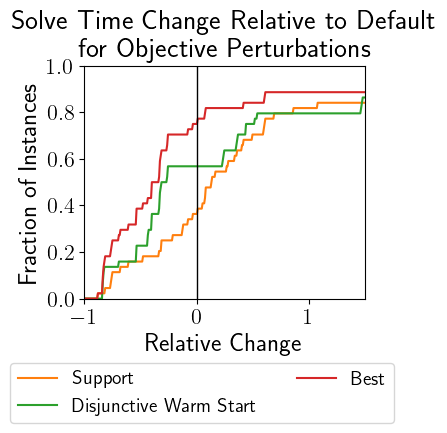

(4, 19)


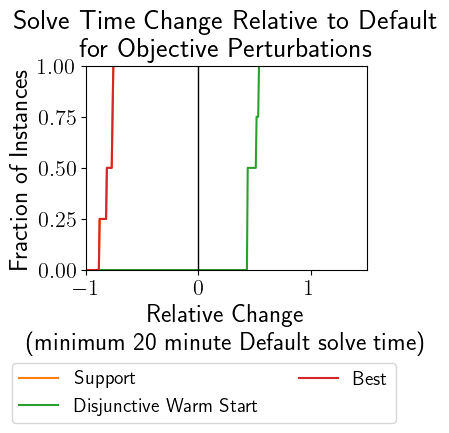

In [94]:
plot_distributions(time_df, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1.5), ylim=(0, 1), bins=350, perturbation="objective", relative=True, best=True, split_panels=False)
plot_distributions(time_df, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1.5), ylim=(0, 1), bins=350, perturbation="objective", relative=True, best=True, split_panels=False, min_value=1200)

(16, 19)


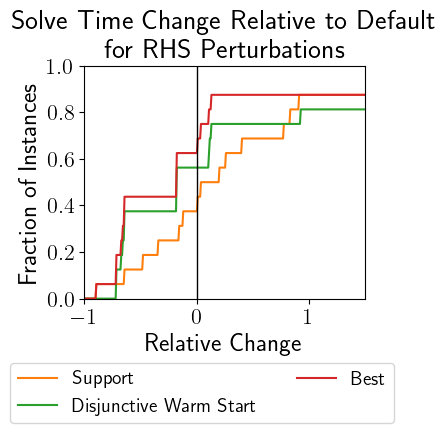

(0, 19)


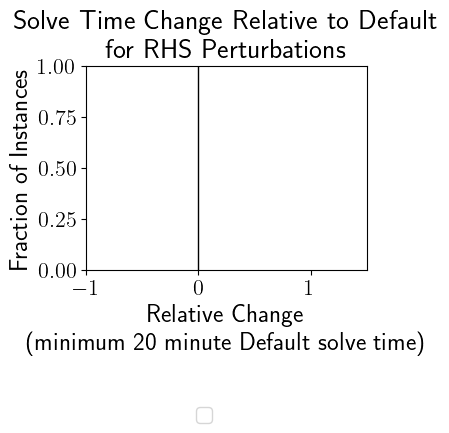

In [95]:
plot_distributions(time_df, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1.5), ylim=(0, 1), bins=350, perturbation="rhs", relative=True, best=True, split_panels=False)
plot_distributions(time_df, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1.5), ylim=(0, 1), bins=350, perturbation="rhs", relative=True, best=True, split_panels=False, min_value=1200)